# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

# LOAD DATA

In [2]:
df = pd.read_csv('new_car.csv')

# DATA OVERVIEW

In [3]:
df.head(5)

,Brand,Model,Engine_Size_L,Horsepower,Fuel_Type,Transmission,Mileage_kmpl,Showroom_Price_INR
0,Volkswagen,Virtus,1.2,131.0,CNG,Automatic,16.8,1726292.0
1,Volkswagen,Polo,1.9,194.0,Diesel,Manual,20.2,2209108.0
2,Toyota,Innova,2.3,167.0,CNG,Automatic,22.0,2206000.0
3,Skoda,Slavia,1.9,216.0,Petrol,Manual,12.9,2132669.0
4,Hyundai,Creta,1.9,190.0,Electric,Automatic,14.7,2909888.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Brand               485 non-null    object 
 1   Model               485 non-null    object 
 2   Engine_Size_L       485 non-null    float64
 3   Horsepower          485 non-null    float64
 4   Fuel_Type           485 non-null    object 
 5   Transmission        485 non-null    object 
 6   Mileage_kmpl        485 non-null    float64
 7   Showroom_Price_INR  485 non-null    float64
dtypes: float64(4), object(4)
memory usage: 31.4+ KB


In [5]:
df.describe()

,Engine_Size_L,Horsepower,Mileage_kmpl,Showroom_Price_INR
count,485.000000,485.000000,485.000000,4.850000e+02
mean,1.738763,148.940206,20.013402,2.111863e+06
std,0.448255,42.827235,4.648550,3.621654e+05
min,1.000000,75.000000,12.000000,1.224017e+06
25%,1.300000,114.000000,15.900000,1.850097e+06
50%,1.700000,148.000000,20.400000,2.097311e+06
75%,2.200000,186.000000,23.900000,2.343380e+06
max,2.500000,220.000000,27.900000,3.076431e+06


In [6]:
df.shape

(500, 8)

In [7]:
df.isnull().sum()

Brand                 15
Model                 15
Engine_Size_L         15
Horsepower            15
Fuel_Type             15
Transmission          15
Mileage_kmpl          15
Showroom_Price_INR    15
dtype: int64

In [8]:
df['Brand'].mode()

0     Skoda
1    Toyota
Name: Brand, dtype: object

In [9]:
df['Brand'] = df['Brand'].fillna(df['Brand'].mode()[0])

# HANDLING MISSING VALUES

In [10]:
df['Brand'].isnull().sum()

np.int64(0)

In [11]:
df['Model'].mode()

0    Altroz
1     Sonet
Name: Model, dtype: object

In [12]:
df['Model'] = df['Model'].fillna(df['Model'].mode()[0])

In [13]:
df['Engine_Size_L'].skew()

np.float64(-0.00597662316981906)

In [14]:
df['Engine_Size_L'] = df['Engine_Size_L'].fillna(df['Engine_Size_L'].mean())

In [15]:
df['Fuel_Type'] = df['Fuel_Type'].fillna(df['Fuel_Type'].mode()[0])

In [16]:
df['Horsepower'].skew()

np.float64(-0.049693552861729204)

In [17]:
df['Horsepower'] = df['Horsepower'].fillna(df['Horsepower'].mean())

In [18]:
df['Mileage_kmpl'].skew()

np.float64(-0.045648720535116975)

In [19]:
df['Mileage_kmpl'] = df['Mileage_kmpl'].fillna(df['Mileage_kmpl'].mean())

In [20]:
df['Showroom_Price_INR'].skew()

np.float64(0.2774740759952488)

In [21]:
df['Showroom_Price_INR'] = df['Showroom_Price_INR'].fillna(df['Showroom_Price_INR'].mean())

In [22]:
df['Transmission'] = df['Transmission'].fillna(df['Transmission'].mode()[0])

In [23]:
df.isnull().sum()

Brand                 0
Model                 0
Engine_Size_L         0
Horsepower            0
Fuel_Type             0
Transmission          0
Mileage_kmpl          0
Showroom_Price_INR    0
dtype: int64

# EXPLORATORY DATA ANALYSIS

In [24]:
brand_wise_avg_price = df.groupby('Brand')['Showroom_Price_INR'].mean().round(2).sort_values(ascending=False)
brand_wise_avg_price

Brand
Hyundai       2187551.28
Skoda         2158985.31
Maruti        2146843.81
Tata          2141430.09
Mahindra      2131757.52
Honda         2108827.71
Volkswagen    2108261.57
Kia           2075052.44
Toyota        2044571.72
MG            2018318.12
Name: Showroom_Price_INR, dtype: float64

In [25]:
model_wise_avg_price = df.groupby("Model")['Showroom_Price_INR'].mean().round(2).sort_values(ascending=False)
model_wise_avg_price

Model
Slavia     2239157.44
i20        2214266.50
Virtus     2212530.71
Creta      2206503.75
Swift      2201565.08
Punch      2188806.40
Altroz     2176641.95
XUV300     2155051.94
XUV700     2143150.40
Elevate    2129391.97
Kushaq     2128976.65
Sonet      2124341.27
Brezza     2122800.31
Seltos     2117737.58
Superb     2115318.27
Scorpio    2112116.33
Nexon      2109372.54
Comet      2106346.00
Polo       2100629.14
Baleno     2092929.11
Amaze      2092359.59
Innova     2077684.80
Hector     2077107.90
City       2067493.92
Venue      2059733.83
Hyryder    2046788.76
Taigun     2013035.59
Glanza     2000824.75
Carens     1992233.06
Astor      1887149.42
Name: Showroom_Price_INR, dtype: float64

In [26]:
fuel_wise_avg_price = df.groupby('Fuel_Type')['Showroom_Price_INR'].mean().round(2).sort_values(ascending=False)
fuel_wise_avg_price

Fuel_Type
Electric    2485130.52
Diesel      2050192.41
CNG         1982941.33
Petrol      1931487.96
Name: Showroom_Price_INR, dtype: float64

In [27]:
trans_wise_avg_price = df.groupby('Transmission')['Showroom_Price_INR'].mean().round(2).sort_values(ascending=False)
trans_wise_avg_price

Transmission
Automatic    2163330.20
Manual       2054288.52
Name: Showroom_Price_INR, dtype: float64

In [28]:
fuel_wise_eng_size = df.groupby('Fuel_Type')['Engine_Size_L'].mean().round(2).sort_values(ascending=False)
fuel_wise_eng_size

Fuel_Type
Petrol      1.75
CNG         1.74
Electric    1.74
Diesel      1.73
Name: Engine_Size_L, dtype: float64

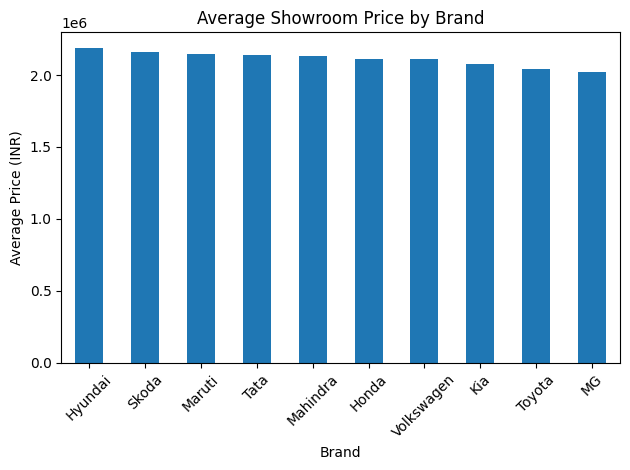

In [29]:
brand_wise_avg_price.plot(kind='bar', xlabel='Brand', ylabel='Average Price (INR)', title='Average Showroom Price by Brand')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

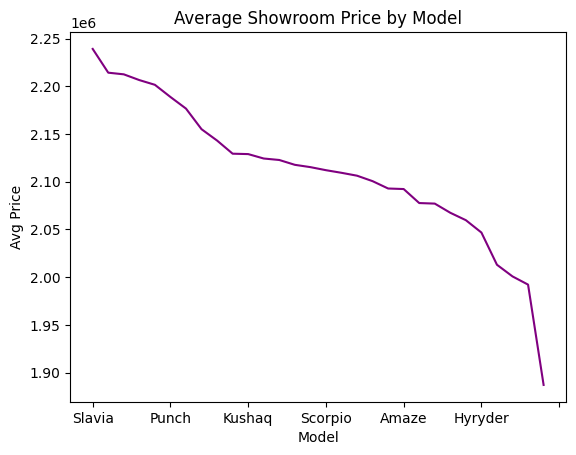

In [30]:
model_wise_avg_price.plot(kind='line',xlabel="Model",ylabel="Avg Price",title='Average Showroom Price by Model',color='purple')
plt.show()

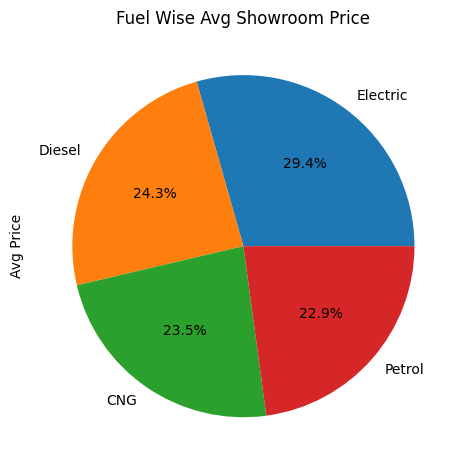

In [31]:
fuel_wise_avg_price.plot(kind='pie',xlabel="Fuel",ylabel="Avg Price",title="Fuel Wise Avg Showroom Price",autopct='%1.1f%%')
plt.tight_layout()
plt.show()

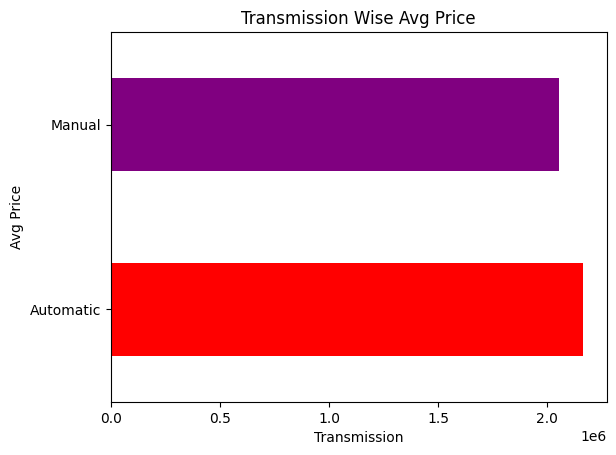

In [32]:
colors=['red','purple']
trans_wise_avg_price.plot(kind='barh',xlabel="Transmission",ylabel='Avg Price',title="Transmission Wise Avg Price",color=colors)
plt.show()

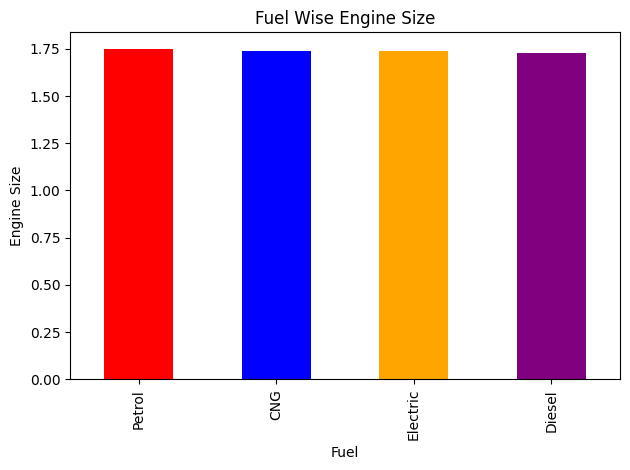

In [33]:
colors=['red','blue','orange','purple']
fuel_wise_eng_size.plot(kind='bar',xlabel="Fuel",ylabel="Engine Size",title="Fuel Wise Engine Size",color=colors)
plt.tight_layout()
plt.show()

In [34]:
df.head(5)

,Brand,Model,Engine_Size_L,Horsepower,Fuel_Type,Transmission,Mileage_kmpl,Showroom_Price_INR
0,Volkswagen,Virtus,1.2,131.0,CNG,Automatic,16.8,1726292.0
1,Volkswagen,Polo,1.9,194.0,Diesel,Manual,20.2,2209108.0
2,Toyota,Innova,2.3,167.0,CNG,Automatic,22.0,2206000.0
3,Skoda,Slavia,1.9,216.0,Petrol,Manual,12.9,2132669.0
4,Hyundai,Creta,1.9,190.0,Electric,Automatic,14.7,2909888.0


# Model Preprocessing

In [35]:
df = pd.get_dummies(df,columns=['Brand','Model','Fuel_Type','Transmission'],dtype=int)
df.head(5)

,Engine_Size_L,Horsepower,Mileage_kmpl,Showroom_Price_INR,Brand_Honda,Brand_Hyundai,Brand_Kia,Brand_MG,Brand_Mahindra,Brand_Maruti,...,Model_Virtus,Model_XUV300,Model_XUV700,Model_i20,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
0,1.2,131.0,16.8,1726292.0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
1,1.9,194.0,20.2,2209108.0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,2.3,167.0,22.0,2206000.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
3,1.9,216.0,12.9,2132669.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
4,1.9,190.0,14.7,2909888.0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [36]:
df.columns

Index(['Engine_Size_L', 'Horsepower', 'Mileage_kmpl', 'Showroom_Price_INR',
       'Brand_Honda', 'Brand_Hyundai', 'Brand_Kia', 'Brand_MG',
       'Brand_Mahindra', 'Brand_Maruti', 'Brand_Skoda', 'Brand_Tata',
       'Brand_Toyota', 'Brand_Volkswagen', 'Model_Altroz', 'Model_Amaze',
       'Model_Astor', 'Model_Baleno', 'Model_Brezza', 'Model_Carens',
       'Model_City', 'Model_Comet', 'Model_Creta', 'Model_Elevate',
       'Model_Glanza', 'Model_Hector', 'Model_Hyryder', 'Model_Innova',
       'Model_Kushaq', 'Model_Nexon', 'Model_Polo', 'Model_Punch',
       'Model_Scorpio', 'Model_Seltos', 'Model_Slavia', 'Model_Sonet',
       'Model_Superb', 'Model_Swift', 'Model_Taigun', 'Model_Venue',
       'Model_Virtus', 'Model_XUV300', 'Model_XUV700', 'Model_i20',
       'Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Fuel_Type_Electric',
       'Fuel_Type_Petrol', 'Transmission_Automatic', 'Transmission_Manual'],
      dtype='object')

In [37]:
x = df[['Engine_Size_L','Horsepower','Mileage_kmpl','Brand_Honda', 'Brand_Hyundai', 'Brand_Kia', 'Brand_MG',
       'Brand_Mahindra', 'Brand_Maruti', 'Brand_Skoda', 'Brand_Tata',
       'Brand_Toyota', 'Brand_Volkswagen', 'Model_Altroz', 'Model_Amaze',
       'Model_Astor', 'Model_Baleno', 'Model_Brezza', 'Model_Carens',
       'Model_City', 'Model_Comet', 'Model_Creta', 'Model_Elevate',
       'Model_Glanza', 'Model_Hector', 'Model_Hyryder', 'Model_Innova',
       'Model_Kushaq', 'Model_Nexon', 'Model_Polo', 'Model_Punch',
       'Model_Scorpio', 'Model_Seltos', 'Model_Slavia', 'Model_Sonet',
       'Model_Superb', 'Model_Swift', 'Model_Taigun', 'Model_Venue',
       'Model_Virtus', 'Model_XUV300', 'Model_XUV700', 'Model_i20',
       'Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Fuel_Type_Electric',
       'Fuel_Type_Petrol', 'Transmission_Automatic', 'Transmission_Manual']]
y = df['Showroom_Price_INR']

In [38]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

# MODEL

In [39]:
model = LinearRegression()

In [40]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](49,)","[ 257148.88, 4962.21, 9777.31,...,-203740.25, 75611.35, -75611.35]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](49,)","['Engine_Size_L','Horsepower','Mileage_kmpl',...,'Fuel_Type_Petrol', 'Transmission_Automatic','Transmission_Manual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.25e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,49
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,44


In [42]:
import pickle
pickle.dump(model,open('Car_Price_Prediction.pkl','wb'))

In [43]:
y_pred = model.predict(x_test)

In [44]:
error = y_test - y_pred

In [45]:
comparision = pd.DataFrame({"Actual":y_test,
                            "Predicted":y_pred.round(2),
                            "Error":error})
comparision.head(5)

,Actual,Predicted,Error
361,1800002.0,1781622.75,18379.254247
73,2390741.0,2299634.60,91106.404499
374,2683146.0,2325388.87,357757.131904
155,2177567.0,2353314.59,-175747.591027
104,2499957.0,2290323.61,209633.394059


# Model Evaluation

In [46]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
evaluation = pd.DataFrame({"MAE":[round(mae,2)],
                           "MSE":[round(mse,2)],
                           "RMSE":[round(rmse,2)],
                           "R2_Score":[round(r2,2)]})
evaluation

,MAE,MSE,RMSE,R2_Score
0,95750.42,1.620158e+10,127285.41,0.87


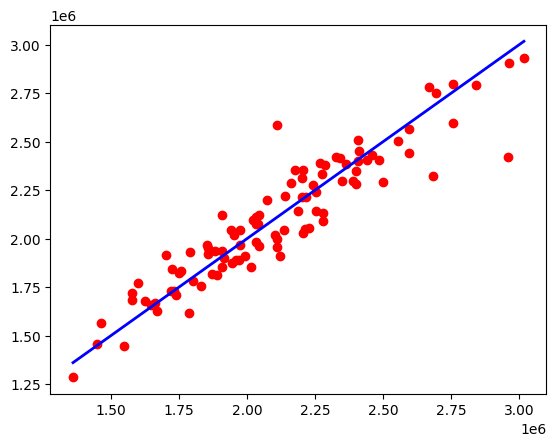

In [47]:
plt.scatter(y_test,y_pred,color='red')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='blue',
    linewidth=2,
    label='Ideal Line'
)
plt.show()

# Prediction

In [48]:
sample_data = [[
    1.5,    # Engine_Size_L
    115,    # Horsepower
    18.5,   # Mileage_kmpl

    # Brand
    0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

    # Model
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

    # Fuel Type
    0, 0, 0, 1,

    # Transmission
    1, 0
]]
new_pred = pd.DataFrame({'Predicted':model.predict(sample_data).round(2)})
new_pred

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Predicted
0,1666602.04


# **Conclusion**

A Multiple Linear Regression model was built to predict car showroom prices. After preprocessing the data and training the model, it achieved the following results:

* **MAE:** 95,750.42
* **MSE:** 16,201,580,000
* **RMSE:** 127,285.41
* **R² Score:** 0.87

The **R² Score of 0.87** means the model explains **87% of the variation** in car prices, indicating good performance. Overall, the model predicts car prices accurately and can be used as a reliable baseline for car price prediction.
